# Import Modules

In [17]:
#high level modules
import os
import importlib.util
from functools import partial
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [18]:

def import_from_path(module_name, file_path):
    spec = importlib.util.spec_from_file_location(module_name, file_path)
    module = importlib.util.module_from_spec(spec)
    sys.modules[module_name] = module
    spec.loader.exec_module(module)
    return module

universal_dir = "/Users/steeleb/Documents/GitHub/TLS_DSS/model_submodule/tiny_model_operation/functions/"
this_dir = "/Users/steeleb/Documents/GitHub/TLS_DSS/model_submodule/forecast_rollout/"

import_from_path("universals", os.path.join(universal_dir, "universal_functions.py"))
from universals import load_pickle_file, twotemp_labels_features_test, predict_2_values_test, return_test_error_metrics

import_from_path("vis", os.path.join(universal_dir, "vis_functions.py"))
from vis import create_scatter_plot_test

import_from_path("forecast_fx", os.path.join(this_dir, "forecast_functions.py"))
from forecast_fx import prep_features, static_regime_tiny, pulsed_regime_tiny, rollout_forecast_operational

dump_dir = "/Users/steeleb/Documents/GitHub/TLS_DSS/DSS_Shiny/www/forecast_operational/"


In [19]:
model_dir = "/Users/steeleb/Documents/GitHub/TLS_DSS/model_submodule/tiny_model_operation/model/"

model_1 = load_pickle_file("model_1.pkl", model_dir)
model_2 = load_pickle_file("model_2.pkl", model_dir)
model_3 = load_pickle_file("model_3.pkl", model_dir)
model_4 = load_pickle_file("model_4.pkl", model_dir)
model_5 = load_pickle_file("model_5.pkl", model_dir)

In [20]:
data_dir = "/Users/steeleb/Documents/GitHub/TLS_DSS/model_submodule/forecast_rollout/data/"

test = pd.read_csv(os.path.join(data_dir, "model_data.csv"))

test["date"] = pd.to_datetime(test["date"])

# need to remove additional variables
# reduce to fewer variables
drop_cols = ['total_solar_radiation_m2', 'mean_rel_hum_m2', 
       'pump_cfs_m2', 'pump_cfs_m3', 'nf_cfs_m2', 'nf_cfs_m3', 'nf_cfs_m4',
       'chipmunk_cfs_m2', 'chipmunk_cfs_m3', 'chipmunk_cfs_m4']

test = test.drop(columns = drop_cols)

test.columns

Index(['date', 'mean_1m_temp_degC', 'mean_0_5m_temp_degC',
       'mean_1m_temp_degC_m1', 'mean_0_5m_temp_degC_m1',
       'total_solar_radiation', 'total_solar_radiation_m1', 'mean_air_temp',
       'min_air_temp', 'max_air_temp', 'mean_air_temp_m1', 'min_air_temp_m1',
       'max_air_temp_m1', 'mean_rel_hum_m1', 'pump_cfs_m1', 'mean_wind',
       'max_wind', 'mean_wind_m1', 'max_wind_m1', 'nf_cfs_m1',
       'chipmunk_cfs_m1'],
      dtype='object')

These columns need to be in the same order as the training data, so just do a quick check of that.

In [21]:
training = pd.read_csv("/Users/steeleb/Documents/GitHub/TLS_DSS/model_submodule/tiny_model_operation/data/training_1.csv")

print(training.columns == test.columns)

[ True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True]


These match.

Now, becasue we have all the data for 2024, let's just look at performance so we even know if we're in the ball park.

For this and future assessments, we need the z score mean/sd values

In [22]:
transform = pd.read_csv("/Users/steeleb/Documents/GitHub/TLS_DSS/model_submodule/model_dev/data/mu_sigma.csv", index_col=0)

t_mean_1m = transform['mean'].get('mean_1m_temp_degC')
t_std_1m = transform['sd'].get('mean_1m_temp_degC')

t_mean_05m = transform['mean'].get('mean_0_5m_temp_degC')
t_std_05m = transform['sd'].get('mean_0_5m_temp_degC')

Make predictions

In [23]:
features, labels = twotemp_labels_features_test(test)

test_baseline = test.copy()

test_baseline["pred_1m_1"], test_baseline["pred_05m_1"] = predict_2_values_test(model_1, features, t_mean_1m, t_mean_05m, t_std_1m, t_std_05m)
test_baseline["pred_1m_2"], test_baseline["pred_05m_2"] = predict_2_values_test(model_2, features, t_mean_1m, t_mean_05m, t_std_1m, t_std_05m)
test_baseline["pred_1m_3"], test_baseline["pred_05m_3"] = predict_2_values_test(model_3, features, t_mean_1m, t_mean_05m, t_std_1m, t_std_05m)
test_baseline["pred_1m_4"], test_baseline["pred_05m_4"] = predict_2_values_test(model_4, features, t_mean_1m, t_mean_05m, t_std_1m, t_std_05m)
test_baseline["pred_1m_5"], test_baseline["pred_05m_5"] = predict_2_values_test(model_5, features, t_mean_1m, t_mean_05m, t_std_1m, t_std_05m)


Make figs

In [24]:
test_baseline["ts_cv_ensemble_pred_1m"] = np.mean(test_baseline[['pred_1m_1', 'pred_1m_2', 'pred_1m_3', 'pred_1m_4', 'pred_1m_5']], axis=1)
test_baseline["ts_cv_ensemble_pred_05m"] = np.mean(test_baseline[['pred_05m_1', 'pred_05m_2', 'pred_05m_3', 'pred_05m_4', 'pred_05m_5']], axis=1)
test_baseline['mean_1m_temp_degC'] = test_baseline['mean_1m_temp_degC'] * t_std_1m + t_mean_1m
test_baseline['mean_0_5m_temp_degC'] = test_baseline['mean_0_5m_temp_degC'] * t_std_05m + t_mean_05m

metrics_1m = return_test_error_metrics(test_baseline["mean_1m_temp_degC"], test_baseline["ts_cv_ensemble_pred_1m"])
metrics_int = return_test_error_metrics(test_baseline["mean_0_5m_temp_degC"], test_baseline["ts_cv_ensemble_pred_05m"])

print(metrics_1m, metrics_int)

Test Datset Error Metrics:
Mean Squared Error: 0.4480331866095759
Mean Absolute Error: 0.5165556710806587
Root Mean Squared Error: 0.6693528117589228
Mean Absolute Percentage Error: 0.034321178451137864
Test Datset Error Metrics:
Mean Squared Error: 0.3891206828180505
Mean Absolute Error: 0.476520585195918
Root Mean Squared Error: 0.623795385377329
Mean Absolute Percentage Error: 0.03739160999449017
(0.4480331866095759, 0.5165556710806587, 0.6693528117589228, 0.034321178451137864) (0.3891206828180505, 0.476520585195918, 0.623795385377329, 0.03739160999449017)


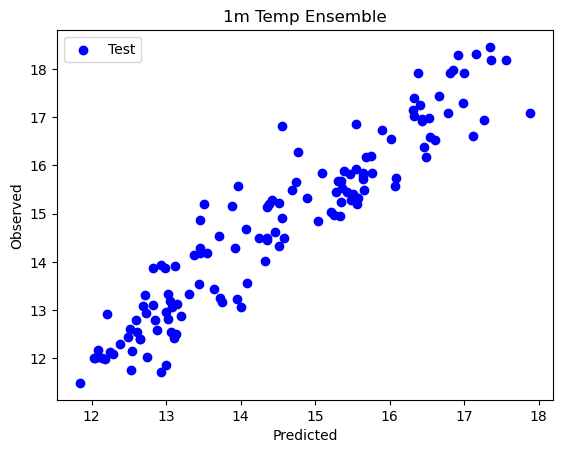

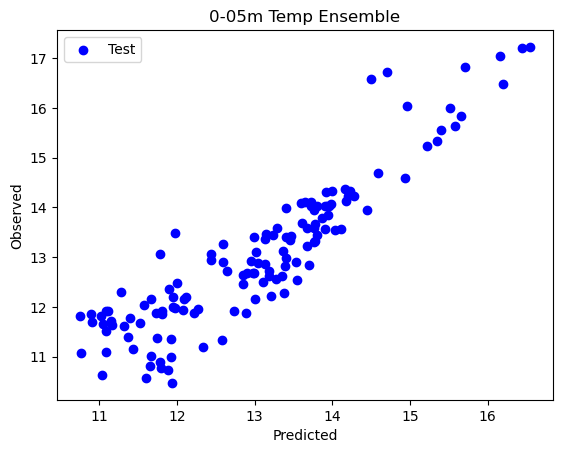

In [25]:
create_scatter_plot_test("1m Temp Ensemble", test_baseline["ts_cv_ensemble_pred_1m"], test_baseline["mean_1m_temp_degC"])
create_scatter_plot_test("0-05m Temp Ensemble", test_baseline["ts_cv_ensemble_pred_05m"], test_baseline["mean_0_5m_temp_degC"])

Now we need to prep the data for forecasting. This step uses a single date and grabs the data seven days in the future. Data are recoded as needed, and a forecast date column is created - this is the date that the forecast is made. 

In [26]:
# make a list of dates from 2024-05-01 to 2024-11-01

all_dates = pd.date_range(start="2024-05-01", end="2024-11-01", freq="D").strftime("%Y-%m-%d")

control_dataset = pd.concat([prep_features(one_date=d, data=test, regime="control") for d in all_dates])
pumping_dataset = pd.concat([prep_features(one_date=d, data=test, regime="altered") for d in all_dates])
control_dataset["forecast_date"] = pd.to_datetime(control_dataset["forecast_date"])
pumping_dataset["forecast_date"] = pd.to_datetime(pumping_dataset["forecast_date"])

# get the unique dates from the control/pumping datsets
unique_dates = control_dataset["forecast_date"].unique()


Great Now that we have a basic data set, we'll fill in the pump data with values for the next 7 days. These need to be reflective of the previous data, too, so we'll use the control data to fill in some of the data.

These are the columns for pumping:
'pump_cfs_m1', 'pump_cfs_m2', 'pump_cfs_m3'

First, we need transformed values to enter into the array. 

In [27]:
transformations = pd.read_csv("/Users/steeleb/Documents/GitHub/TLS_DSS/model_submodule/model_dev/data/mu_sigma.csv", index_col=0)

# get the index callled "pump_cfs"
x = transformations.loc[transformations.index == "pump_cfs", :].values
# calculate z score using the mean (first value) and the std (second value)
transformed_zero = (0 - x[0][0]) / x[0][1]
transformed_220 = (220 - x[0][0]) / x[0][1]
transformed_440 = (440 - x[0][0]) / x[0][1]

print(transformed_zero, transformed_220, transformed_440)

-0.8701765874092859 0.22381065604391792 1.3177978994971216


And now, using the functions for 'static' and 'pulsed' operational regimes, we'll create two datasets for forecasting.

In [28]:
# create a dataframe for static pump of 220, using the control data to manipulate the m1, m2, m3 columns.
zero_pump = pd.concat([static_regime_tiny(data = pumping_dataset, control = control_dataset, one_date = d, flow = transformed_zero) for d in unique_dates])

# create a dataframe for static pump of 220, using the control data to manipulate the m1, m2, m3 columns.
static_pump = pd.concat([static_regime_tiny(data = pumping_dataset, control = control_dataset, one_date = d, flow = transformed_220) for d in unique_dates])

# do the same for pulsing pumped, where there is a separate weekday/weekend flow
pulsed_pump = pd.concat([pulsed_regime_tiny(data = pumping_dataset, control = control_dataset, one_date = d, weekday_flow = transformed_440, weekend_flow = transformed_220) for d in unique_dates])

# Roll out forecast

Here, we're just iteratively modeling, for each of the 4 models for the next 7 days. First, we need to remove any columns that aren't in the model proper, and we need to make sure the order of the columns is the same as the training set. To do this, we'll just select the feature names in the proper order.

In [12]:
control_dataset.columns

Index(['mean_1m_temp_degC', 'mean_0_5m_temp_degC', 'mean_1m_temp_degC_m1',
       'mean_0_5m_temp_degC_m1', 'total_solar_radiation',
       'total_solar_radiation_m1', 'mean_air_temp', 'min_air_temp',
       'max_air_temp', 'mean_air_temp_m1', 'min_air_temp_m1',
       'max_air_temp_m1', 'mean_rel_hum_m1', 'pump_cfs_m1', 'mean_wind',
       'max_wind', 'mean_wind_m1', 'max_wind_m1', 'nf_cfs_m1',
       'chipmunk_cfs_m1', 'forecast_date'],
      dtype='object')

In [29]:
# get the feature names from the operational training file
upstream_names = pd.read_csv(os.path.join( "/Users/steeleb/Documents/GitHub/TLS_DSS/model_submodule/model_dev/operational_model/data/training_1.csv"))
# reduce to fewer variables
drop_cols = ['total_solar_radiation_m2', 'mean_rel_hum_m2', 
       'pump_cfs_m2', 'pump_cfs_m3', 'nf_cfs_m2', 'nf_cfs_m3', 'nf_cfs_m4',
       'chipmunk_cfs_m2', 'chipmunk_cfs_m3', 'chipmunk_cfs_m4']

feature_names = upstream_names.drop(columns = drop_cols).columns

# remove date, and two target columns (first 3 columns)
feature_names = feature_names[3:]
feature_names = list(feature_names) + ["forecast_date"]

# and get those features in order for each dataset! (but we also need the forecast date!)
control_for_model = control_dataset[feature_names].copy()
zero_for_model = zero_pump[feature_names].copy()
static_for_model = static_pump[feature_names].copy()
pulsing_for_model = pulsed_pump[feature_names].copy()


And now rollout the forecast per unique valid date.

In [30]:
control_forecasts = (pd.concat([rollout_forecast_operational(data = control_for_model, 
                                                 m1 = model_1, m2 = model_2, m3 = model_3, m4 = model_4, m5 = model_5,
                                                 fore_date = d) for d in unique_dates]))

In [31]:
# we need to back transform the data for mean 1m and mean 0.5m
control_forecasts["mean_1m_temp_degC"] = control_forecasts["mean_1m_temp_degC"] * transformations.loc["mean_1m_temp_degC", "sd"] + transformations.loc["mean_1m_temp_degC", "mean"]
control_forecasts["mean_0_5m_temp_degC"] = control_forecasts["mean_0_5m_temp_degC"] * transformations.loc["mean_0_5m_temp_degC", "sd"] + transformations.loc["mean_0_5m_temp_degC", "mean"]

export_features = ["forecast_date", "valid_date", "model", "mean_1m_temp_degC", "mean_0_5m_temp_degC"]
control_forecasts[export_features]
# save the files to csv
control_forecasts.to_csv(os.path.join(dump_dir, "forecasted_temp_control_collated.csv"), index=False)

In [32]:
zero_forecasts = (pd.concat([rollout_forecast_operational(data = zero_for_model, 
                                                 m1 = model_1, m2 = model_2, m3 = model_3, m4 = model_4, m5 = model_5,
                                                 fore_date = d) for d in unique_dates]))

In [33]:
# we need to back transform the data for mean 1m and mean 0.5m
zero_forecasts["mean_1m_temp_degC"] = zero_forecasts["mean_1m_temp_degC"] * transformations.loc["mean_1m_temp_degC", "sd"] + transformations.loc["mean_1m_temp_degC", "mean"]
zero_forecasts["mean_0_5m_temp_degC"] = zero_forecasts["mean_0_5m_temp_degC"] * transformations.loc["mean_0_5m_temp_degC", "sd"] + transformations.loc["mean_0_5m_temp_degC", "mean"]

zero_forecasts = zero_forecasts[export_features]
# save the files to csv
zero_forecasts.to_csv(os.path.join(dump_dir, "forecasted_temp_zero_collated.csv"), index=False)

In [34]:
static_forecast = (pd.concat([rollout_forecast_operational(data = static_for_model, 
                                                 m1 = model_1, m2 = model_2, m3 = model_3, m4 = model_4, m5 = model_5,
                                                 fore_date = d) for d in unique_dates]))

In [35]:
# we need to back transform the data for mean 1m and mean 0.5m
static_forecast["mean_1m_temp_degC"] = static_forecast["mean_1m_temp_degC"] * transformations.loc["mean_1m_temp_degC", "sd"] + transformations.loc["mean_1m_temp_degC", "mean"]
static_forecast["mean_0_5m_temp_degC"] = static_forecast["mean_0_5m_temp_degC"] * transformations.loc["mean_0_5m_temp_degC", "sd"] + transformations.loc["mean_0_5m_temp_degC", "mean"]

# only grab the features we care about
static_forecast[export_features]

# save the files to csv
static_forecast.to_csv(os.path.join(dump_dir, "forecasted_temp_static_collated.csv"), index=False)

In [36]:
pulsing_forecast = (pd.concat([rollout_forecast_operational(data = pulsing_for_model, 
                                                 m1 = model_1, m2 = model_2, m3 = model_3, m4 = model_4, m5 = model_5,
                                                 fore_date = d) for d in unique_dates]))

In [37]:
# we need to back transform the data for mean 1m and mean 0.5m
pulsing_forecast["mean_1m_temp_degC"] = pulsing_forecast["mean_1m_temp_degC"] * transformations.loc["mean_1m_temp_degC", "sd"] + transformations.loc["mean_1m_temp_degC", "mean"]
pulsing_forecast["mean_0_5m_temp_degC"] = pulsing_forecast["mean_0_5m_temp_degC"] * transformations.loc["mean_0_5m_temp_degC", "sd"] + transformations.loc["mean_0_5m_temp_degC", "mean"]

# only grab the features we care about
pulsing_forecast[export_features]

# save the files to csv
pulsing_forecast.to_csv(os.path.join(dump_dir, "forecasted_temp_pulsing_collated.csv"), index=False)